In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/wiii8/probability_of_contact.csv')
df1['condition'] = 'wiii8'


df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/anosmic/probability_of_contact.csv')
df2['condition'] = 'anosmic'


df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/9047/probability_of_contact.csv')
df3['condition'] = '9047'

df4 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/23129/probability_of_contact.csv')
df4['condition'] = '23129'

df5 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/sensory/33300/probability_of_contact.csv')
df5['condition'] = '33300'

df = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)



condition_order = ['wiii8', 'anosmic', '9047', '23129', '33300']

condition_colors = {
    'wiii8': '#385491',
    'anosmic': '#be0f0a',
    '9047': '#e7533a',
    '23129': '#fc8c59',
    '33300': "#fead61",
}

# only complete encounters: the larva came within 10 mm and left again
complete = df[df['end_reason'] == 'exit']

print(complete.groupby('condition').size())


condition
23129      2526
33300      1557
9047       2053
anosmic    2461
wiii8      2592
dtype: int64


      comparison    U        p significance
anosmic vs wiii8  5.0 0.000769          ***
   9047 vs wiii8 15.0 0.009108           **
  23129 vs wiii8 13.0 0.005795           **
  33300 vs wiii8 21.0 0.031209            *

           p_contact  n_files
condition                    
23129          0.289       10
33300          0.343       10
9047           0.338       10
anosmic        0.219       10
wiii8          0.456       10


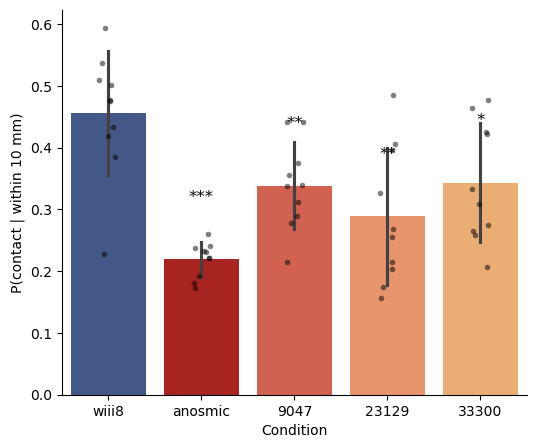

In [2]:
from scipy.stats import mannwhitneyu

# probability of contact per larva, then averaged per dish
per_larva = (
    complete.groupby(['condition', 'file', 'focal_id'], as_index=False)
            .agg(p_contact=('contacted', 'mean'), n_encounters=('contacted', 'size'))
)

per_file = (
    per_larva.groupby(['condition', 'file'], as_index=False)
             .agg(p_contact=('p_contact', 'mean'), n_encounters=('n_encounters', 'mean'))
)

control = per_file.loc[per_file['condition'] == 'wiii8', 'p_contact']
stats_rows = []

for condition in condition_order:
    if condition == 'wiii8':
        continue

    test_group = per_file.loc[per_file['condition'] == condition, 'p_contact']
    u_stat, p_value = mannwhitneyu(test_group, control, alternative='two-sided')

    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns'

    stats_rows.append({
        'comparison': f'{condition} vs wiii8',
        'U': u_stat,
        'p': p_value,
        'significance': significance,
    })

stats_table = pd.DataFrame(stats_rows)
print(stats_table.to_string(index=False))
print()
print(per_file.groupby('condition').agg(p_contact=('p_contact', 'mean'), n_files=('file', 'size')).round(3))

plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=per_file,
    x='condition',
    y='p_contact',
    order=condition_order,
    hue='condition',
    hue_order=condition_order,
    palette=condition_colors,
    errorbar='sd',
    legend=False,
)

sns.stripplot(
    data=per_file,
    x='condition',
    y='p_contact',
    order=condition_order,
    color='black',
    size=4,
    alpha=0.5,
    ax=ax,
)

y_offset = per_file['p_contact'].max() * 0.15
for row in stats_rows:
    condition = row['comparison'].split(' vs ')[0]
    x = condition_order.index(condition)
    y = per_file.loc[per_file['condition'] == condition, 'p_contact'].mean() + y_offset
    ax.text(x, y, row['significance'], ha='center', va='bottom', fontsize=12)

plt.ylim(0, None)
plt.ylabel('P(contact | within 10 mm)')
plt.xlabel('Condition')
sns.despine()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/sensory-mutants/probability_of_contact.pdf', format='pdf')
plt.show()


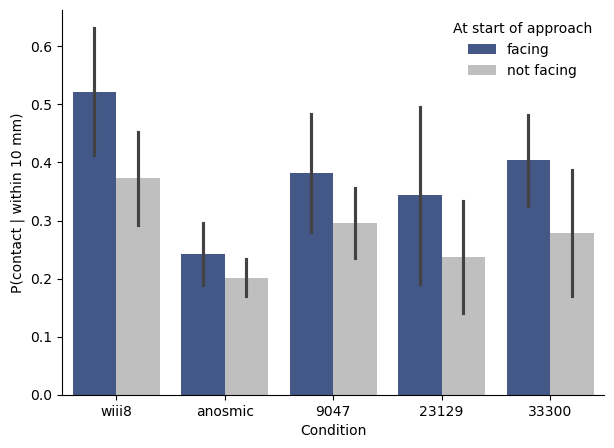

approach   facing  not facing
condition                    
23129       0.343       0.237
33300       0.404       0.279
9047        0.381       0.296
anosmic     0.242       0.202
wiii8       0.522       0.373


In [3]:
# same thing, split by whether the larva was pointing at the other one at the start

per_larva_angle = (
    complete.groupby(['condition', 'file', 'focal_id', 'facing_at_start'], as_index=False)
            .agg(p_contact=('contacted', 'mean'), n_encounters=('contacted', 'size'))
)

per_file_angle = (
    per_larva_angle.groupby(['condition', 'file', 'facing_at_start'], as_index=False)
                   .agg(p_contact=('p_contact', 'mean'))
)

per_file_angle['approach'] = np.where(
    per_file_angle['facing_at_start'], 'facing', 'not facing'
)

plt.figure(figsize=(7,5))

sns.barplot(
    data=per_file_angle,
    x='condition',
    y='p_contact',
    order=condition_order,
    hue='approach',
    hue_order=['facing', 'not facing'],
    palette=['#385491', '#bfbfbf'],
    errorbar='sd',
)

plt.ylim(0, None)
plt.ylabel('P(contact | within 10 mm)')
plt.xlabel('Condition')
plt.legend(title='At start of approach', frameon=False)
sns.despine()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/sensory-mutants/probability_of_contact_angle.pdf', format='pdf')
plt.show()

print(per_file_angle.groupby(['condition', 'approach'])['p_contact'].mean().unstack().round(3))


      comparison    U        p significance
anosmic vs wiii8 38.0 0.384673           ns
   9047 vs wiii8 20.5 0.028306            *
  23129 vs wiii8 41.0 0.520523           ns
  33300 vs wiii8  5.0 0.000769          ***


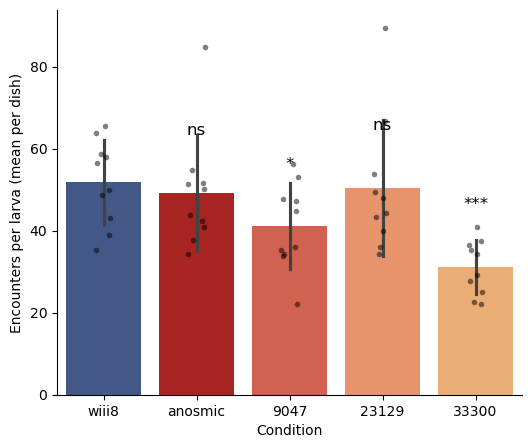

In [4]:
# how often they meet at all, so a difference in probability isn't confused with a difference in encounter rate

control = per_file.loc[per_file['condition'] == 'wiii8', 'n_encounters']
stats_rows = []

for condition in condition_order:
    if condition == 'wiii8':
        continue

    test_group = per_file.loc[per_file['condition'] == condition, 'n_encounters']
    u_stat, p_value = mannwhitneyu(test_group, control, alternative='two-sided')

    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns'

    stats_rows.append({
        'comparison': f'{condition} vs wiii8',
        'U': u_stat,
        'p': p_value,
        'significance': significance,
    })

print(pd.DataFrame(stats_rows).to_string(index=False))

plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=per_file,
    x='condition',
    y='n_encounters',
    order=condition_order,
    hue='condition',
    hue_order=condition_order,
    palette=condition_colors,
    errorbar='sd',
    legend=False,
)

sns.stripplot(
    data=per_file,
    x='condition',
    y='n_encounters',
    order=condition_order,
    color='black',
    size=4,
    alpha=0.5,
    ax=ax,
)

y_offset = per_file['n_encounters'].max() * 0.15
for row in stats_rows:
    condition = row['comparison'].split(' vs ')[0]
    x = condition_order.index(condition)
    y = per_file.loc[per_file['condition'] == condition, 'n_encounters'].mean() + y_offset
    ax.text(x, y, row['significance'], ha='center', va='bottom', fontsize=12)

plt.ylim(0, None)
plt.ylabel('Encounters per larva (mean per dish)')
plt.xlabel('Condition')
sns.despine()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/sensory-mutants/encounters_per_larva.pdf', format='pdf')
plt.show()
